# Genome-wide selection scans: G123 and F_ST

This notebook computes and visualises two population-genetic statistics across the *An. farauti* ss genome,
restricted to the three populations sampled from Australia and Torres Strait / southern New Guinea.

| Population | Region |
|---|---|
| `farauti_ss-QLD-Mainland` | Queensland, Australia |
| `farauti_ss-AUNT` | Northern Territory, Australia |
| `farauti_ss-TSI-sNG` | Torres Strait Islands / southern New Guinea |

---

### G123

G123 (Garud et al. 2015, *Genetics*) is a **diplotype-homozygosity** statistic sensitive to recent positive selection.
It works by sliding a window of fixed SNP count across the genome and, within each window, asking:
*how often do two randomly drawn individuals carry exactly the same pair of haplotypes?*
In a neutral population, diplotypes are shuffled by recombination and genetic drift, so no single diplotype dominates.
After a selective sweep, the favoured haplotype pair is driven up in frequency, producing a spike in G123.

Formally, if $f_1 \ge f_2 \ge f_3 \ge \ldots$ are diplotype frequencies (sorted descending):
$$G123 = (f_1 + f_2 + f_3)^2 + \sum_{i \ge 4} f_i^2$$

### F_ST

Hudson's $F_{ST}$ (Bhatia et al. 2013, *Genome Research*) measures **genetic differentiation** between two populations
in each window. Values near 0 mean the populations are similar at that locus; values near 1 mean they carry
almost entirely different alleles. Peaks of $F_{ST}$ between populations can point to loci under
population-specific selection or barriers to gene flow, or vice versa.

Here we compute all three pairwise comparisons among the target populations.

---

**Window size**: `WINDOW_SIZE` SNPs per window (set in the next cell).  
Results are cached as `.npy` files so the scan only needs to run once.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import zarr
import allel
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## Setup

Point to the phased store, the sample metadata, and the cache directories where intermediate
results are saved.  Adjust `WINDOW_SIZE` if you want coarser or finer resolution. You will want to modify the paths here

In [2]:
ZARR_BASE      = "/scratch/user/uqtdenni/afar_production_bunya/curation/uq-beebe-001/staged_zarr/{contig}.zarr"
META_PATH      = "/scratch/user/uqtdenni/far_hin_1.x/work/metadata_development_20250702/metadata-staged-cohorts-20260312.txt"
CACHE_DIR_G123 = "/scratch/user/uqtdenni/github/farauti-qld-paper/data/g123"
CACHE_DIR_FST  = "/scratch/user/uqtdenni/github/farauti-qld-paper/data/fst"
WINDOW_SIZE    = 10_000

os.makedirs(CACHE_DIR_G123, exist_ok=True)
os.makedirs(CACHE_DIR_FST,  exist_ok=True)

df_samples = pd.read_csv(META_PATH, index_col=0)

contigs = sorted([
    f.replace(".zarr", "")
    for f in os.listdir(os.path.dirname(ZARR_BASE.format(contig="X")))
    if f.endswith(".zarr")
])

# Populations of interest: farauti ss from Australia and TSI / southern New Guinea only
TARGET_POPS = ["farauti_ss-QLD-Mainland", "farauti_ss-AUNT", "farauti_ss-TSI-sNG"]

print(f"{len(df_samples)} samples | {len(contigs)} contigs")
for pop in TARGET_POPS:
    n = (df_samples["analysis_cohort"] == pop).sum()
    print(f"  {pop}: {n} samples")

495 samples | 46 contigs
  farauti_ss-QLD-Mainland: 45 samples
  farauti_ss-AUNT: 30 samples
  farauti_ss-TSI-sNG: 63 samples


### Cohort colors
Plug in the custom cohort mapping here

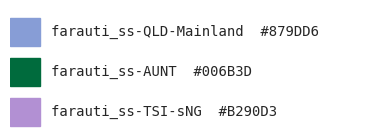

In [13]:
cohort_colors = {
 'farauti_ss-AUNT': '#006B3D',
 'farauti_ss-QLD-Mainland': '#879DD6',
 'farauti_ss-TSI-sNG': '#B290D3',
}

fig, ax = plt.subplots(figsize=(4, len(TARGET_POPS) * 0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(TARGET_POPS))
ax.axis("off")
for i, pop in enumerate(reversed(TARGET_POPS)):
    colour = cohort_colours.get(pop, "#888888")
    ax.add_patch(plt.Rectangle((0, i + 0.1), 0.08, 0.7, color=colour))
    ax.text(0.11, i + 0.45, f"{pop}  {colour}", va="center", fontsize=10, family="monospace")
plt.tight_layout()
plt.show()

### Genome position mapper

The genome is assembled into many contigs.  To plot all contigs on a single x-axis we need to
concatenate them end-to-end.  `GenomePositionMapper` queries the last variant position in each contig
to estimate its length, sorts contigs from longest to shortest (roughly chromosome-order), and assigns
each contig a cumulative offset.  It also assigns alternating colours (lightblue / steelblue) so you
can visually distinguish adjacent contigs — the classic 'zebra stripe' manhattan plot.

In [4]:
class GenomePositionMapper:
    """Maps per-contig variant positions to a linear genome coordinate."""

    def __init__(self, contig_list):
        lengths = {}
        for c in contig_list:
            z = zarr.open_consolidated(ZARR_BASE.format(contig=c), mode="r")
            lengths[c] = int(z["variants/POS"][-1])
        self.sorted_contigs = sorted(lengths, key=lengths.__getitem__, reverse=True)
        cum = np.cumsum([0] + [lengths[c] for c in self.sorted_contigs[:-1]])
        self.offsets = dict(zip(self.sorted_contigs, cum))
        self.color_map = {
            c: ("lightblue" if i % 2 == 0 else "steelblue")
            for i, c in enumerate(self.sorted_contigs)
        }

    def apply(self, df, coord_col):
        df = df.copy()
        df["contig"] = pd.Categorical(df["contig"], categories=self.sorted_contigs, ordered=True)
        df = df.sort_values(["contig", coord_col])
        df["genome_pos"] = df[coord_col] + df["contig"].map(self.offsets).astype(float)
        df["color"] = df["contig"].map(self.color_map)
        return df


mapper = GenomePositionMapper(contigs)
print("Contig order (first 5):", mapper.sorted_contigs[:5])

Contig order (first 5): ['KI915040', 'KI915041', 'KI915042', 'KI915043', 'KI915044']


## G123 — diplotype homozygosity

`garud_g123` takes a (n_variants × n_samples × 2) int8 array — the raw diploid genotype calls for one
window — and returns a single G123 value.  It works by treating each individual's full diplotype
(both haplotypes concatenated) as a byte string, counting how often each unique diplotype appears,
and applying the G123 formula.

`g123_contig` loops over one contig for one population, slides the window using `allel.moving_statistic`,
and caches the result so re-running the notebook is instant.

In [5]:
def garud_g123(gt):
    """G123 statistic (Garud et al. 2015) from a window of diploid genotype calls.

    Parameters
    ----------
    gt : ndarray, shape (n_variants, n_samples, 2), dtype int8
        Diploid genotype calls for one window.

    Returns
    -------
    float
        G123 value in [0, 1].  High values indicate diplotype homozygosity
        consistent with a recent selective sweep.
    """
    n = gt.shape[1]
    keys = [gt[:, i, :].tobytes() for i in range(n)]
    counts = Counter(keys)
    f = np.sort(np.array(list(counts.values()), dtype=float) / n)[::-1]
    if len(f) >= 3:
        return np.sum(f[:3]) ** 2 + np.sum(f[3:] ** 2)
    return np.sum(f) ** 2


def g123_contig(contig, cohort_mask, cohort_name, window_size=WINDOW_SIZE, overwrite=False):
    """Compute windowed G123 for one contig and one cohort.

    Parameters
    ----------
    contig : str
        Contig identifier, e.g. 'KI915040'.
    cohort_mask : pd.Series of bool
        Boolean mask over df_samples rows selecting the target cohort.
    cohort_name : str
        Human-readable name used for cache file paths.
    window_size : int
        Number of SNPs per window.  Can be set as e.g. 1e4 — will be cast to int.
    overwrite : bool
        If True, recompute even if a cache file exists.

    Returns
    -------
    g123 : ndarray, shape (n_windows,)
    mid  : ndarray, shape (n_windows,)  — mean variant position per window
    """
    window_size = int(window_size)

    safe_name  = cohort_name.replace("/", "_").replace(" ", "_")
    cache_g123 = os.path.join(CACHE_DIR_G123, f"{contig}__{safe_name}__w{window_size}__g123.npy")
    cache_pos  = os.path.join(CACHE_DIR_G123, f"{contig}__{safe_name}__w{window_size}__pos.npy")

    if not overwrite and os.path.exists(cache_g123):
        return np.load(cache_g123), np.load(cache_pos)

    z = zarr.open_consolidated(ZARR_BASE.format(contig=contig), mode="r")
    cohort_idx = np.where(cohort_mask.values)[0]
    gt_cohort  = z["calldata/GT"].oindex[:, cohort_idx, :]  # (n_var, n_samples, 2)
    pos        = z["variants/POS"][:]

    g123 = allel.moving_statistic(gt_cohort, statistic=garud_g123, size=window_size)
    mid  = allel.moving_statistic(pos,        statistic=np.mean,    size=window_size)

    np.save(cache_g123, g123)
    np.save(cache_pos, mid)
    print(f"  saved: {contig} ({len(pos):,} variants, {len(g123):,} windows)")
    return g123, mid

In [6]:
def run_g123_cohort(cohort, overwrite=False):
    """Run g123_contig across all contigs for one cohort and return a genome-mapped DataFrame."""
    mask = df_samples["analysis_cohort"] == cohort
    print(f"{cohort} ({mask.sum()} samples)")
    rows = []
    for contig in contigs:
        g123, mid = g123_contig(contig, mask, cohort_name=cohort, overwrite=overwrite)
        for p, v in zip(mid, g123):
            rows.append({"contig": contig, "pos": float(p), "g123": float(v)})
    df = pd.DataFrame(rows)
    return mapper.apply(df, "pos")


def plot_g123_multipanel(pop_dfs, colour_map, title="G123 scans"):
    """Manhattan-style G123 scan, one panel per population.

    Each panel's dots are drawn in that population's colour from ``colour_map``.
    Contig boundaries are shown as alternating light-grey / white background strips.

    Parameters
    ----------
    pop_dfs : dict  {population_name: DataFrame from run_g123_cohort}
    colour_map : dict  {population_name: hex colour string}
    title : str
    """
    sns.set_style("ticks")
    n = len(pop_dfs)
    fig, axes = plt.subplots(n, 1, figsize=(18, 2.5 * n), sharex=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    # Shade alternating contigs as a visual guide
    for ax in axes:
        for i, contig in enumerate(mapper.sorted_contigs):
            offset = mapper.offsets[contig]
            width  = mapper.offsets.get(
                mapper.sorted_contigs[i + 1], None
            ) - offset if i + 1 < len(mapper.sorted_contigs) else None
            if width is None:
                continue
            if i % 2 == 0:
                ax.axvspan(offset, offset + width, color="#f0f0f0", linewidth=0, zorder=0)

    for ax, (pop, df) in zip(axes, pop_dfs.items()):
        colour = colour_map.get(pop, "#888888")
        ax.scatter(
            df["genome_pos"], df["g123"],
            s=15, color=colour, alpha=0.5, linewidths=0, rasterized=True, zorder=1,
        )
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.5, 1])
        ax.tick_params(axis="y", labelsize=8)
        label = ax.set_ylabel(pop, fontsize=9, rotation=0, ha="right", va="center", labelpad=6)
        label.set_color(colour)
        sns.despine(ax=ax, bottom=True, left=False)

    axes[-1].set_xlabel("Genome position (bp)", fontsize=10)
    sns.despine(ax=axes[-1], bottom=False)
    fig.suptitle(title, fontsize=12)
    plt.show()

Run the G123 scan for all three target populations.  Set `overwrite=True` to force recomputation.

farauti_ss-QLD-Mainland (45 samples)
farauti_ss-AUNT (30 samples)
farauti_ss-TSI-sNG (63 samples)


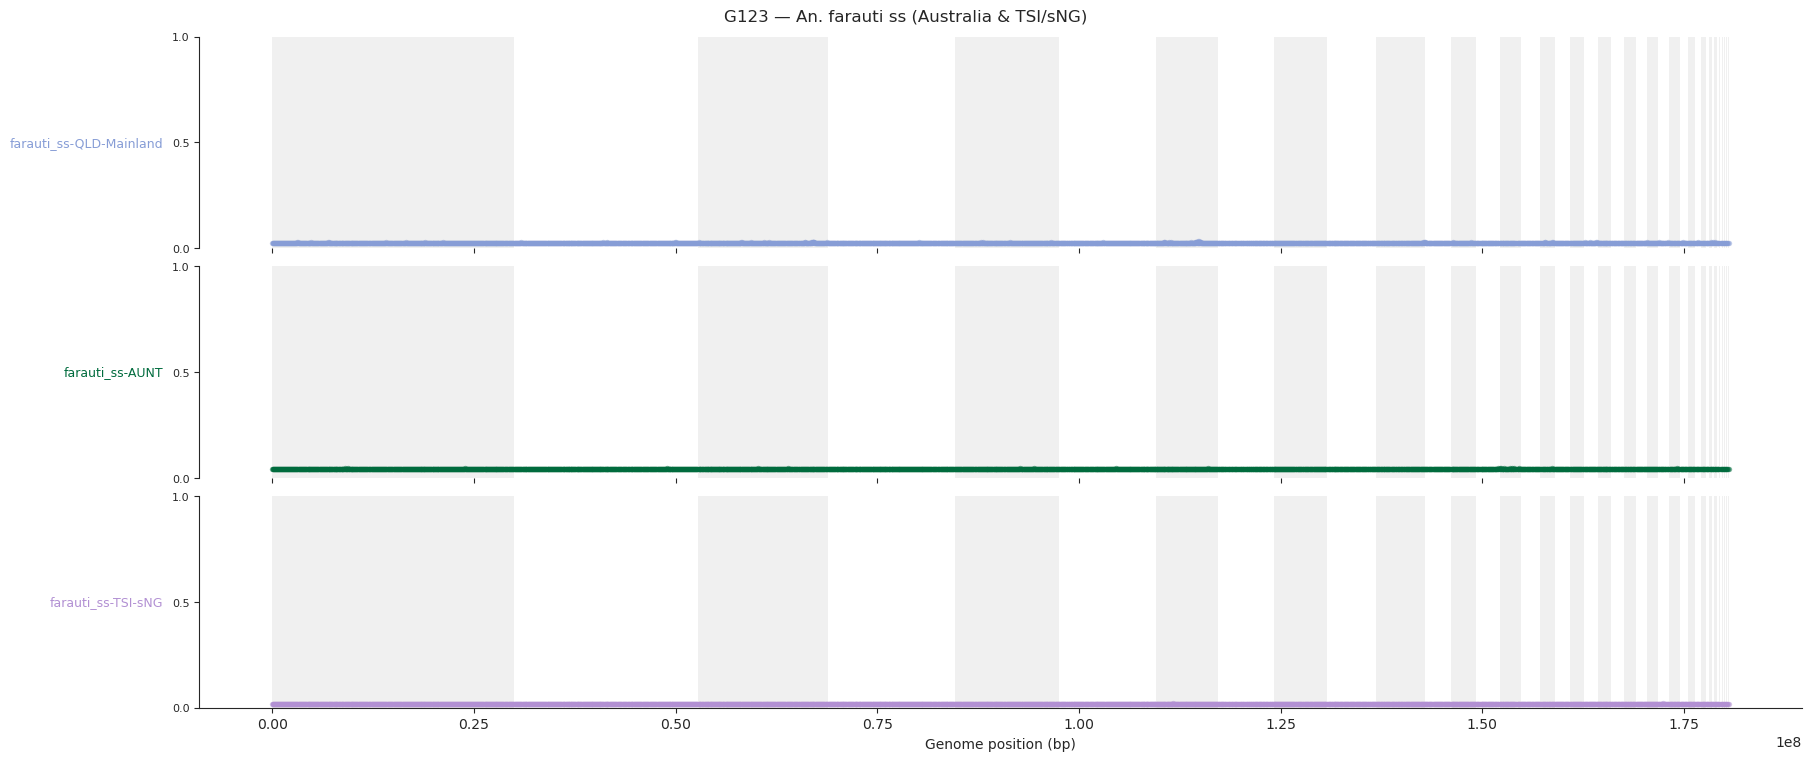

In [7]:
pop_dfs_g123 = {pop: run_g123_cohort(pop) for pop in TARGET_POPS}
plot_g123_multipanel(pop_dfs_g123, colour_map=cohort_colours, title="G123 — An. farauti ss (Australia & TSI/sNG)")

## F_ST — pairwise genetic differentiation

We compute Hudson's windowed $F_{ST}$ for every pair of the three target populations.
Hudson's estimator is preferred over Weir–Cockerham for unequal sample sizes and is
unbiased with respect to sample size differences between populations.

The three comparisons are:
1. **QLD-Mainland vs AUNT** — within Australia, north vs south
2. **QLD-Mainland vs TSI-sNG** — Australia vs the Torres Strait / PNG border zone
3. **AUNT vs TSI-sNG** — Northern Territory vs Torres Strait / PNG

`fst_contig` loads allele counts for both populations, applies `allel.moving_hudson_fst`,
clips small negative values to zero (these can arise by chance in windows with little variation),
and caches results.

In [8]:
def fst_contig(contig, mask_a, mask_b, pair_name, window_size, overwrite=False):
    """Compute windowed Hudson's Fst between two cohorts for one contig.

    Parameters
    ----------
    contig : str
    mask_a, mask_b : pd.Series of bool
        Boolean masks selecting each population from df_samples.
    pair_name : str
        Label used for cache file paths.
    window_size : int
        Number of SNPs per window.  Can be set as e.g. 1e5 — will be cast to int.
    overwrite : bool

    Returns
    -------
    fst : ndarray, shape (n_windows,)  — Hudson Fst, clipped to [0, 1]
    mid : ndarray, shape (n_windows,)  — mean variant position per window
    """
    window_size = int(window_size)

    cache_fst = os.path.join(CACHE_DIR_FST, f"{contig}__{pair_name}__w{window_size}__fst.npy")
    cache_pos = os.path.join(CACHE_DIR_FST, f"{contig}__{pair_name}__w{window_size}__pos.npy")

    if not overwrite and os.path.exists(cache_fst):
        return np.load(cache_fst), np.load(cache_pos)

    z     = zarr.open_consolidated(ZARR_BASE.format(contig=contig), mode="r")
    idx_a = np.where(mask_a.values)[0]
    idx_b = np.where(mask_b.values)[0]

    ac_a = allel.GenotypeArray(z["calldata/GT"].oindex[:, idx_a, :]).count_alleles()
    ac_b = allel.GenotypeArray(z["calldata/GT"].oindex[:, idx_b, :]).count_alleles()
    pos  = z["variants/POS"][:]

    with np.errstate(divide="ignore", invalid="ignore"):
        fst = allel.moving_hudson_fst(ac_a, ac_b, size=window_size)
        fst = np.clip(fst, a_min=0, a_max=1)
    mid = allel.moving_statistic(pos, statistic=np.mean, size=window_size)

    np.save(cache_fst, fst)
    np.save(cache_pos, mid)
    print(f"  saved: {contig} ({len(pos):,} variants, {len(fst):,} windows)")
    return fst, mid

In [9]:
def run_fst_pair(pop_a, pop_b, window_size, overwrite=False):
    """Run fst_contig across all contigs for one population pair."""
    mask_a    = df_samples["analysis_cohort"] == pop_a
    mask_b    = df_samples["analysis_cohort"] == pop_b
    safe_a    = pop_a.replace("/", "_").replace(" ", "_")
    safe_b    = pop_b.replace("/", "_").replace(" ", "_")
    pair_name = f"{safe_a}_vs_{safe_b}"
    print(f"{pop_a} ({mask_a.sum()}) vs {pop_b} ({mask_b.sum()})")
    rows = []
    for contig in contigs:
        fst, mid = fst_contig(contig, mask_a, mask_b, pair_name=pair_name, window_size=window_size, overwrite=overwrite)
        for p, v in zip(mid, fst):
            rows.append({"contig": contig, "pos": float(p), "fst": float(v)})
    df = pd.DataFrame(rows)
    return mapper.apply(df, "pos")


def plot_fst_multipanel(pair_dfs, colour_map, title="Fst scans"):
    """Manhattan-style Fst scan, one panel per population pair.

    Dots are coloured using the first population's colour from ``colour_map``.
    Contig boundaries are shown as alternating light-grey / white background strips.

    Parameters
    ----------
    pair_dfs : dict  {'pop_a vs pop_b': DataFrame from run_fst_pair}
    colour_map : dict  {population_name: hex colour string}
    title : str
    """
    sns.set_style("ticks")
    n = len(pair_dfs)
    fig, axes = plt.subplots(n, 1, figsize=(18, 2.5 * n), sharex=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    # Shade alternating contigs as a visual guide
    for ax in axes:
        for i, contig in enumerate(mapper.sorted_contigs):
            offset = mapper.offsets[contig]
            width  = mapper.offsets.get(
                mapper.sorted_contigs[i + 1], None
            ) - offset if i + 1 < len(mapper.sorted_contigs) else None
            if width is None:
                continue
            if i % 2 == 0:
                ax.axvspan(offset, offset + width, color="#f0f0f0", linewidth=0, zorder=0)

    for ax, (pair_label, df) in zip(axes, pair_dfs.items()):
        # Use the first population's colour; fall back to grey
        pop_a = pair_label.split(" vs ")[0]
        colour = colour_map.get(pop_a, "#888888")
        ax.scatter(
            df["genome_pos"], df["fst"],
            s=15, color=colour, alpha=0.5, linewidths=0, rasterized=True, zorder=1,
        )
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.5, 1])
        ax.tick_params(axis="y", labelsize=8)
        label = ax.set_ylabel(pair_label, fontsize=9, rotation=0, ha="right", va="center", labelpad=6)
        label.set_color(colour)
        sns.despine(ax=ax, bottom=True, left=False)

    axes[-1].set_xlabel("Genome position (bp)", fontsize=10)
    sns.despine(ax=axes[-1], bottom=False)
    fig.suptitle(title, fontsize=12)
    plt.show()

Run all three pairwise $F_{ST}$ scans.  Set `overwrite=True` to recompute cached results.

farauti_ss-QLD-Mainland (45) vs farauti_ss-AUNT (30)
farauti_ss-QLD-Mainland (45) vs farauti_ss-TSI-sNG (63)
farauti_ss-AUNT (30) vs farauti_ss-TSI-sNG (63)


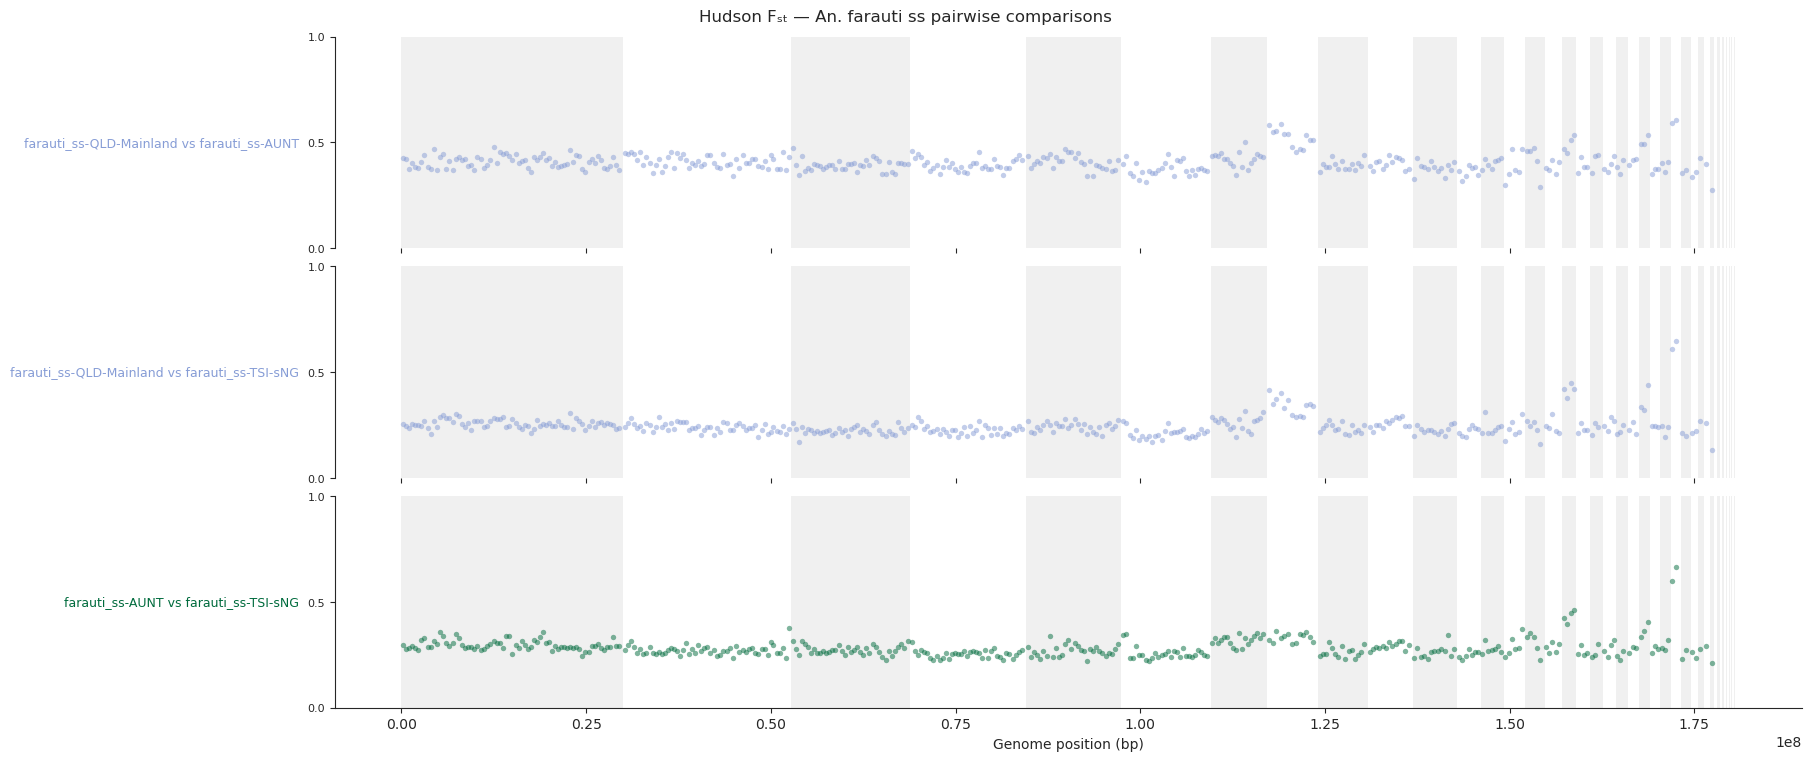

In [10]:
WINDOW_SIZE = 1e5
FST_PAIRS = [
    ("farauti_ss-QLD-Mainland", "farauti_ss-AUNT"),
    ("farauti_ss-QLD-Mainland", "farauti_ss-TSI-sNG"),
    ("farauti_ss-AUNT",         "farauti_ss-TSI-sNG"),
]

pair_dfs = {}
for pop_a, pop_b in FST_PAIRS:
    label = f"{pop_a} vs {pop_b}"
    pair_dfs[label] = run_fst_pair(pop_a, pop_b, window_size = WINDOW_SIZE)

plot_fst_multipanel(pair_dfs, colour_map=cohort_colours, title="Hudson Fₛₜ — An. farauti ss pairwise comparisons")